# House Price Prediction  Ames Housing Dataset
**Junior Data Scientist | Ames, Iowa Real Estate Firm**

This notebook covers EDA, data cleaning, feature engineering, and modeling using only numerical features from the Ames Housing dataset.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')

train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
print(f'Train: {train.shape} | Test: {test.shape}')


Train: (1460, 81) | Test: (1459, 80)


## Part 1 - Exploratory Data Analysis

**Step 1.1 - Filter to numerical columns only.** The brief requires us to drop all object/categorical columns and work solely with int64/float64 types. This is a deliberate constraint to focus on measurable property characteristics.

In [2]:
# Keep only numeric columns; exclude Id (row identifier) and SalePrice (target)
all_num = train.select_dtypes(include=['int64','float64']).columns.tolist()
features = [c for c in all_num if c not in ['Id','SalePrice']]

print(f'Number of numerical features (excl. Id & SalePrice): {len(features)}')
print('\nFeatures:')
for i, f in enumerate(features, 1):
    print(f'  {i:2d}. {f}')


Number of numerical features (excl. Id & SalePrice): 36

Features:
   1. MSSubClass
   2. LotFrontage
   3. LotArea
   4. OverallQual
   5. OverallCond
   6. YearBuilt
   7. YearRemodAdd
   8. MasVnrArea
   9. BsmtFinSF1
  10. BsmtFinSF2
  11. BsmtUnfSF
  12. TotalBsmtSF
  13. 1stFlrSF
  14. 2ndFlrSF
  15. LowQualFinSF
  16. GrLivArea
  17. BsmtFullBath
  18. BsmtHalfBath
  19. FullBath
  20. HalfBath
  21. BedroomAbvGr
  22. KitchenAbvGr
  23. TotRmsAbvGrd
  24. Fireplaces
  25. GarageYrBlt
  26. GarageCars
  27. GarageArea
  28. WoodDeckSF
  29. OpenPorchSF
  30. EnclosedPorch
  31. 3SsnPorch
  32. ScreenPorch
  33. PoolArea
  34. MiscVal
  35. MoSold
  36. YrSold


After filtering, we are left with **36 numerical features**. These span physical measurements (square footage, lot size), quality ratings (OverallQual), counts (bedrooms, bathrooms, fireplaces), and temporal fields (year built, year sold).

**Step 1.2 - Top 5 features by correlation with SalePrice and heatmap.** Pearson correlation gives us a fast linear signal ranking; the heatmap also reveals multicollinearity between predictors.

Top 5 features by |correlation| with SalePrice:
  OverallQual: 0.7910
  GrLivArea: 0.7086
  GarageCars: 0.6404
  GarageArea: 0.6234
  TotalBsmtSF: 0.6136


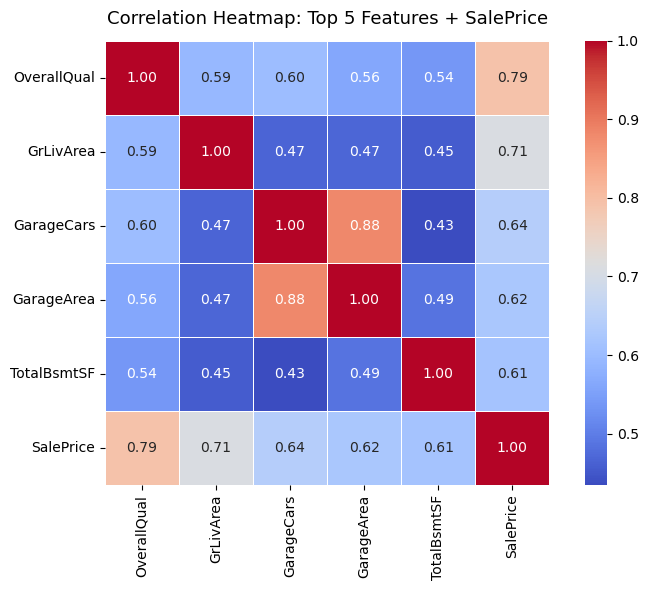

In [3]:
corr_sp = train[features + ['SalePrice']].corr()['SalePrice'].drop('SalePrice')
top5 = corr_sp.abs().sort_values(ascending=False).head(5).index.tolist()

print('Top 5 features by |correlation| with SalePrice:')
for feat in top5:
    print(f'  {feat}: {corr_sp[feat]:.4f}')

fig, ax = plt.subplots(figsize=(8, 6))
cm = train[top5 + ['SalePrice']].corr()
sns.heatmap(cm, annot=True, fmt='.2f', cmap='coolwarm', ax=ax,
            square=True, linewidths=0.5)
ax.set_title('Correlation Heatmap: Top 5 Features + SalePrice', fontsize=13, pad=12)
plt.tight_layout()
plt.show()


The top 5 features are: **OverallQual (0.79), GrLivArea (0.71), GarageCars (0.64), GarageArea (0.62), TotalBsmtSF (0.61)**.

Note: GarageCars and GarageArea are highly correlated with each other (0.88), flagging a multicollinearity issue we will address in Part 2.

**Step 1.3 - Scatter plots for top 3 features.** Visualising each feature against SalePrice to assess linearity and spot outliers.

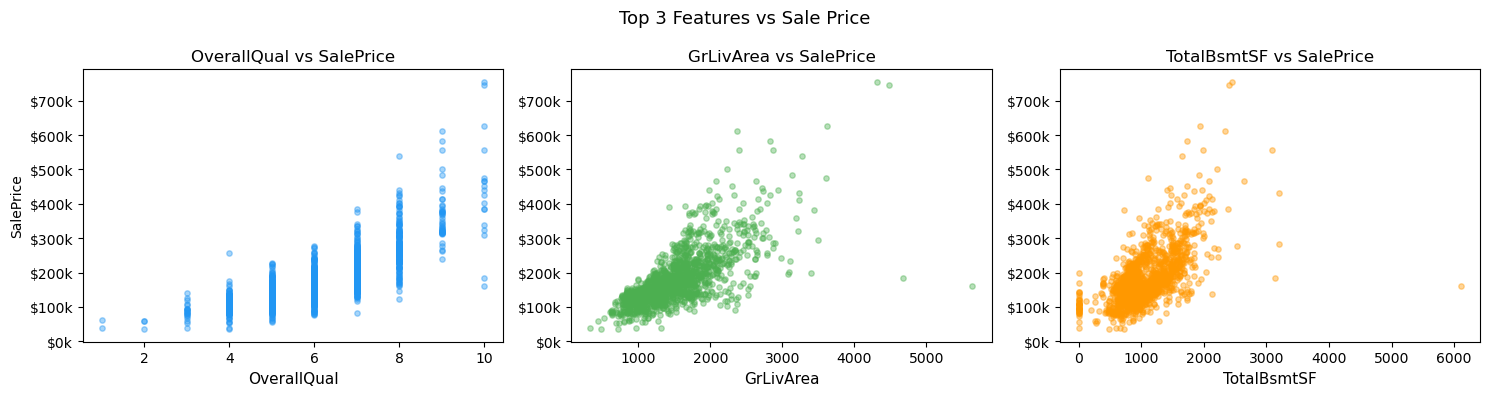

In [4]:
top3 = ['OverallQual', 'GrLivArea', 'TotalBsmtSF']
colors = ['#2196F3', '#4CAF50', '#FF9800']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, (feat, col) in enumerate(zip(top3, colors)):
    axes[i].scatter(train[feat], train['SalePrice'], alpha=0.4, s=15, color=col)
    axes[i].set_xlabel(feat, fontsize=11)
    axes[i].set_ylabel('SalePrice' if i == 0 else '')
    axes[i].set_title(f'{feat} vs SalePrice')
    axes[i].yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}k'))
plt.suptitle('Top 3 Features vs Sale Price', fontsize=13)
plt.tight_layout()
plt.show()


**Patterns observed:**

- **OverallQual**: Near-monotonic positive relationship - higher quality consistently means higher price. The spread widens at quality 8-10, suggesting heteroscedasticity. The relationship is ordinal rather than perfectly linear.

- **GrLivArea**: Generally linear positive trend, but two extreme-right observations (>4,000 sqft) have surprisingly low prices - these are likely partial sales or data entry errors and will be treated as outliers.

- **TotalBsmtSF**: Broadly linear, with more variance at higher values. Houses with zero basement (TotalBsmtSF = 0) are a discrete sub-group visible at the left edge.

**Step 1.4 - SalePrice distribution check.** We need to understand whether SalePrice is normally distributed, as linear regression assumes normally distributed errors.

Skewness (raw):      1.8829
Skewness (log):      0.1213


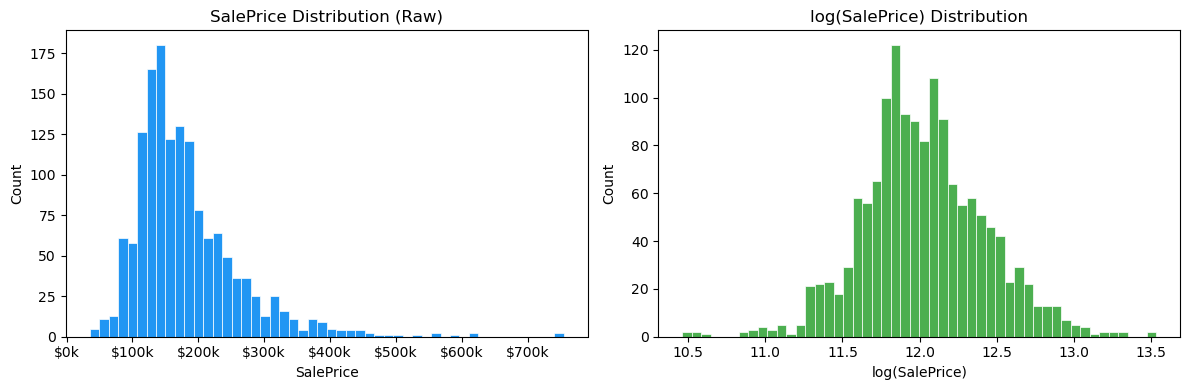

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(train['SalePrice'], bins=50, color='#2196F3',
             edgecolor='white', linewidth=0.5)
axes[0].set_title('SalePrice Distribution (Raw)')
axes[0].set_xlabel('SalePrice')
axes[0].set_ylabel('Count')
axes[0].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}k'))

axes[1].hist(np.log(train['SalePrice']), bins=50, color='#4CAF50',
             edgecolor='white', linewidth=0.5)
axes[1].set_title('log(SalePrice) Distribution')
axes[1].set_xlabel('log(SalePrice)')
axes[1].set_ylabel('Count')

skew_raw = train['SalePrice'].skew()
skew_log = np.log(train['SalePrice']).skew()
print(f'Skewness (raw):      {skew_raw:.4f}')
print(f'Skewness (log):      {skew_log:.4f}')

plt.tight_layout()
plt.show()


**Raw SalePrice** has a skewness of ~1.88 - a strong right skew. A long right tail means a few very expensive houses pull the mean up. **Problem for linear regression:** OLS assumes normally distributed residuals; a skewed target causes the model to disproportionately penalise large errors at the high end, biasing coefficient estimates.

**Log-transforming SalePrice** (skewness drops to ~0.12) produces a near-normal distribution. This is exactly what the Kaggle competition uses for scoring (RMSE on log-scale), and it is what we will use throughout.

**Step 1.5 - Outlier identification and decision.** Using the GrLivArea scatter plot, we identified two clear anomalies where large houses sold for unusually low prices.

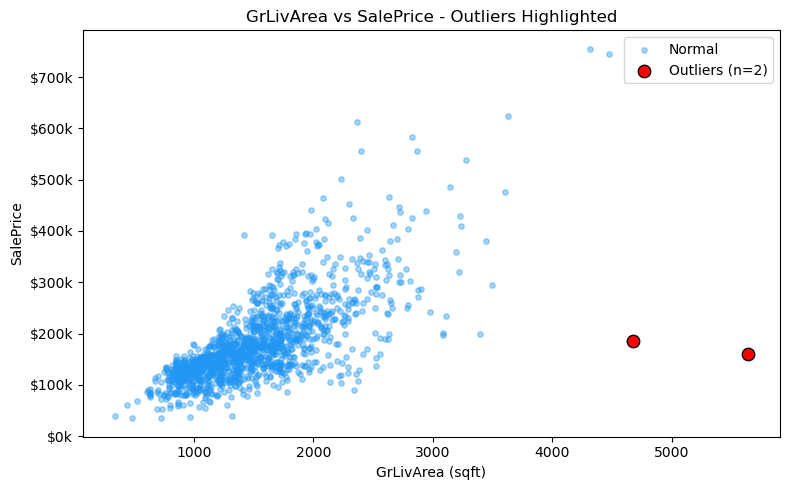

Outlier details:
        Id  GrLivArea  SalePrice  OverallQual SaleCondition
523    524       4676     184750           10       Partial
1298  1299       5642     160000           10       Partial


In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(train['GrLivArea'], train['SalePrice'],
           alpha=0.4, s=15, color='#2196F3', label='Normal')

outlier_mask = (train['GrLivArea'] > 4000) & (train['SalePrice'] < 300000)
ax.scatter(train.loc[outlier_mask, 'GrLivArea'],
           train.loc[outlier_mask, 'SalePrice'],
           color='red', s=80, zorder=5,
           label=f'Outliers (n={outlier_mask.sum()})', edgecolors='black')

ax.set_xlabel('GrLivArea (sqft)')
ax.set_ylabel('SalePrice')
ax.set_title('GrLivArea vs SalePrice - Outliers Highlighted')
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}k'))
plt.tight_layout()
plt.show()

print('Outlier details:')
print(train.loc[outlier_mask,
      ['Id','GrLivArea','SalePrice','OverallQual','SaleCondition']].to_string())


**Three outlier groups identified:**

1. **Id 524 & 1299 (GrLivArea > 4,000 sqft, price < $200k)** - Both have OverallQual = 10 (Very Excellent) yet sold for roughly $160-185k. This is implausible for the Ames market and is flagged as either a partial sale, foreclosure, or data issue. **Decision: DROP** — they would distort the regression slope for GrLivArea badly.

2. **Very high-priced normal homes (>$700k)** - These exist but follow the trend. **Decision: KEEP** - they are legitimate luxury sales.

3. **Potential low-price anomalies (<$40k)** - A handful of homes sold for under $50k. These are likely salvage/condemned properties (SaleCondition = Abnorml). **Decision: KEEP** - removing too many low-price observations would introduce selection bias.

In [8]:
# Drop the two confirmed outliers
train = train[~outlier_mask].copy()
print(f'Train shape after dropping outliers: {train.shape}')


Train shape after dropping outliers: (1458, 81)



## Part 2 - Data Cleaning


**Step 2.1 - Handle missing values with feature-specific justifications.** A blanket `fillna(0)` would be misleading for features where 0 has a real meaning (e.g., GarageYrBlt = 0 is impossible for a real garage).

In [9]:
print('Missing values in numerical features (train):')
missing = train[features].isnull().sum()
print(missing[missing > 0])


Missing values in numerical features (train):
LotFrontage    259
MasVnrArea       8
GarageYrBlt     81
dtype: int64


In [10]:
# LotFrontage (259 missing, ~18%): fill with median.
# Justification: LotFrontage is a continuous measurement; median is robust to
# the right skew in lot sizes and is preferable to mean here.
lot_median = train['LotFrontage'].median()
train['LotFrontage'] = train['LotFrontage'].fillna(lot_median)
test['LotFrontage'] = test['LotFrontage'].fillna(lot_median)
print(f'LotFrontage filled with median: {lot_median}')

# MasVnrArea (8 missing, <1%): fill with 0.
# Justification: a missing masonry veneer area almost certainly means no masonry
# veneer exists, so 0 sqft is the correct semantic value.
train['MasVnrArea'] = train['MasVnrArea'].fillna(0)
test['MasVnrArea'] = test['MasVnrArea'].fillna(0)
print('MasVnrArea filled with 0 (no masonry veneer)')

# GarageYrBlt (81 missing, ~5.5%): fill with 0.
# Justification: GarageYrBlt is NA when there is NO garage at all (consistent
# with GarageType = NA for the same rows). A year of 0 is not a real year,
# but it cleanly separates 'no garage' from any real build year, and we will
# later engineer HouseAge-style features where 0 remains interpretable.
train['GarageYrBlt'] = train['GarageYrBlt'].fillna(0)
test['GarageYrBlt'] = test['GarageYrBlt'].fillna(0)
print('GarageYrBlt filled with 0 (no garage)')

# Any remaining test-set missings: fill with training median
for col in features:
    if col in test.columns and test[col].isnull().sum() > 0:
        test[col] = test[col].fillna(train[col].median())

print('\nRemaining missing (train):', train[features].isnull().sum().sum())
print('Remaining missing (test):', test[features].isnull().sum().sum())


LotFrontage filled with median: 69.0
MasVnrArea filled with 0 (no masonry veneer)
GarageYrBlt filled with 0 (no garage)

Remaining missing (train): 0
Remaining missing (test): 0


**Step 2.2 - Detect and address multicollinearity.** Two predictors that are near-identical reduce interpretability and inflate coefficient variance in OLS. We check for pairs with |r| > 0.8.

In [11]:
corr_mat = train[features].corr().abs()
upper = corr_mat.where(np.triu(np.ones(corr_mat.shape), k=1).astype(bool))

high_corr = [(col, idx, upper.loc[idx, col])
             for col in upper.columns for idx in upper.index
             if upper.loc[idx, col] > 0.8]

print('Pairs with |correlation| > 0.8:')
for a, b, v in sorted(high_corr, key=lambda x: -x[2]):
    print(f'  {a:20s} <-> {b:20s}: {v:.3f}')


Pairs with |correlation| > 0.8:
  GarageArea           <-> GarageCars          : 0.887
  TotRmsAbvGrd         <-> GrLivArea           : 0.829
  1stFlrSF             <-> TotalBsmtSF         : 0.804


In [12]:
# Decision:
# GarageArea vs GarageCars (0.887): DROP GarageCars — GarageArea in sqft is
#   a continuous, more precise measurement; car capacity is a rounded integer.
# TotRmsAbvGrd vs GrLivArea (0.829): DROP TotRmsAbvGrd — GrLivArea (sqft)
#   is a direct physical measurement; room count is correlated but cruder.
# 1stFlrSF vs TotalBsmtSF (0.804): KEEP BOTH — they measure different floors;
#   correlation is real but each retains independent variance we want to capture.

to_drop_multicollinear = ['GarageCars', 'TotRmsAbvGrd']
features_clean = [f for f in features if f not in to_drop_multicollinear]
print(f'Features after multicollinearity pruning: {len(features_clean)}')


Features after multicollinearity pruning: 34


**Step 2.3 - Scale features.** Scaling is necessary for linear regression with regularization. Without it, Ridge penalizes large-coefficient features more simply because their raw units are larger (e.g., LotArea in sqft vs. FullBath as a count of 1–3), creating an unfair regularization bias.

In [13]:
# We defer fitting the scaler until after feature engineering (Part 3)
# so engineered features are also scaled on the same scale.
print('StandardScaler will be applied after feature engineering (Part 3).')
print('It subtracts the mean and divides by std for each feature,')
print('ensuring no single feature dominates the L2 penalty in Ridge.')


StandardScaler will be applied after feature engineering (Part 3).
It subtracts the mean and divides by std for each feature,
ensuring no single feature dominates the L2 penalty in Ridge.



## Part 3 - Feature Engineering


**Step 3.1 - Create new numerical features from existing ones.** Good features compress multiple correlated columns into single interpretable signals, often improving model performance.

In [14]:
for df in [train, test]:
    # TotalSF: total above-ground + basement area gives the best single proxy
    # for house size; each sub-component is already correlated with price.
    df['TotalSF'] = df['1stFlrSF'] + df['2ndFlrSF'] + df['TotalBsmtSF']

    # HouseAge: years from construction to sale date captures obsolescence
    # and renovation demand; older homes generally sell for less, ceteris paribus.
    df['HouseAge'] = df['YrSold'] - df['YearBuilt']

    # TotalBathrooms: combines full and half baths above and below grade into
    # one score; a half-bath counts as 0.5 per convention.
    df['TotalBathrooms'] = (df['FullBath'] + 0.5 * df['HalfBath'] +
                            df['BsmtFullBath'] + 0.5 * df['BsmtHalfBath'])

    # YearsSinceRemodel: captures how recently the house was updated; a freshly
    # remodelled home should command a premium over an identical but dated one.
    df['YearsSinceRemodel'] = df['YrSold'] - df['YearRemodAdd']

eng_features = ['TotalSF', 'HouseAge', 'TotalBathrooms', 'YearsSinceRemodel']

for f in eng_features:
    corr_val = train[[f, 'SalePrice']].corr().iloc[0, 1]
    print(f'{f:25s}: correlation with SalePrice = {corr_val:.4f}')


TotalSF                  : correlation with SalePrice = 0.8329
HouseAge                 : correlation with SalePrice = -0.5241
TotalBathrooms           : correlation with SalePrice = 0.6359
YearsSinceRemodel        : correlation with SalePrice = -0.5097


**Step 3.2 - Log-transform SalePrice.** Applying log(SalePrice) as the target makes the distribution approximately normal (skewness ~0.12 vs ~1.88 raw), satisfying OLS assumptions and preventing the model from over-weighting expensive homes in the loss function.

In [15]:
y = np.log(train['SalePrice'])
print(f'log(SalePrice) — mean: {y.mean():.4f}, std: {y.std():.4f}, skew: {y.skew():.4f}')

# Assemble final feature list
all_features = features_clean + eng_features
print(f'\nTotal features entering model: {len(all_features)}')
print(all_features)


log(SalePrice) — mean: 12.0240, std: 0.3997, skew: 0.1216

Total features entering model: 38
['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'Fireplaces', 'GarageYrBlt', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'TotalSF', 'HouseAge', 'TotalBathrooms', 'YearsSinceRemodel']


In [16]:
# Fit and apply StandardScaler
X_train = train[all_features].copy()
X_test = test[all_features].copy()

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print('Scaling complete. X_train_sc shape:', X_train_sc.shape)


Scaling complete. X_train_sc shape: (1458, 38)



## Part 4 - Modeling & Validation


**Step 4.1 - Baseline linear regression with 5-fold cross-validation.** A single train/test split is unreliable due to randomness in the split; K-fold CV gives a more stable estimate of generalisation error.

In [17]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
lr = LinearRegression()

scores_lr = cross_val_score(lr, X_train_sc, y, cv=kf,
                            scoring='neg_mean_squared_error')
rmse_lr_cv = np.sqrt(-scores_lr)

print('Linear Regression — 5-Fold CV RMSE (log SalePrice):')
for i, r in enumerate(rmse_lr_cv, 1):
    print(f'  Fold {i}: {r:.5f}')
print(f'  Mean: {rmse_lr_cv.mean():.5f}  |  Std: {rmse_lr_cv.std():.5f}')


Linear Regression — 5-Fold CV RMSE (log SalePrice):
  Fold 1: 0.13337
  Fold 2: 0.11819
  Fold 3: 0.14076
  Fold 4: 0.13247
  Fold 5: 0.11993
  Mean: 0.12894  |  Std: 0.00858


**Step 4.2 - Residual analysis.** Examining the residuals on the full training set to understand where the model struggles.

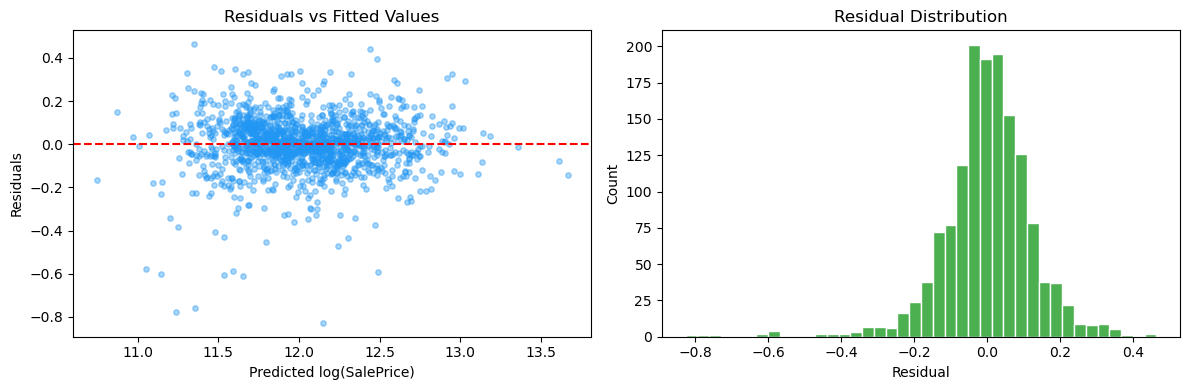

Training RMSE (log): 0.1243650046199513


In [18]:
lr.fit(X_train_sc, y)
y_pred_train = lr.predict(X_train_sc)
residuals = y - y_pred_train

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(y_pred_train, residuals, alpha=0.4, s=15, color='#2196F3')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted log(SalePrice)')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted Values')

axes[1].hist(residuals, bins=40, color='#4CAF50', edgecolor='white')
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution')
plt.tight_layout()
plt.show()

print('Training RMSE (log):', np.sqrt(mean_squared_error(y, y_pred_train)))


**Step 4.3 - Bonus: Ridge Regression.** Ridge (L2 regularization) adds a penalty term λ·||w||² to the OLS loss. This shrinks large coefficients toward zero, reducing variance at the cost of a small bias. It is especially useful when features are correlated.

Best Ridge alpha: 50.0

Ridge Regression — 5-Fold CV RMSE (log SalePrice):
  Fold 1: 0.13447
  Fold 2: 0.11708
  Fold 3: 0.14042
  Fold 4: 0.13235
  Fold 5: 0.12043
  Mean: 0.12895  |  Std: 0.00880


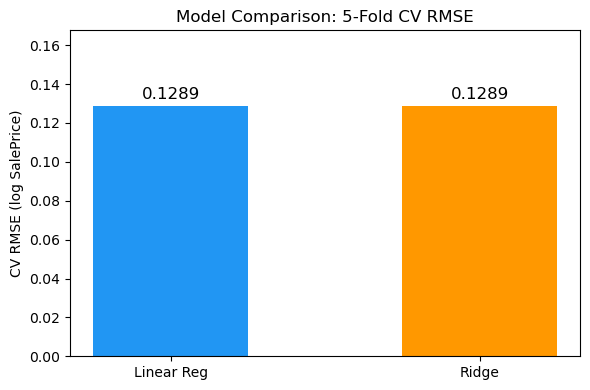

In [19]:
# RidgeCV searches across a grid of alpha values using the same CV folds
ridge = RidgeCV(alphas=[0.01, 0.1, 1, 10, 50, 100, 200, 500], cv=kf)
ridge.fit(X_train_sc, y)
print(f'Best Ridge alpha: {ridge.alpha_}')

scores_ridge = cross_val_score(ridge, X_train_sc, y, cv=kf,
                               scoring='neg_mean_squared_error')
rmse_ridge_cv = np.sqrt(-scores_ridge)

print('\nRidge Regression — 5-Fold CV RMSE (log SalePrice):')
for i, r in enumerate(rmse_ridge_cv, 1):
    print(f'  Fold {i}: {r:.5f}')
print(f'  Mean: {rmse_ridge_cv.mean():.5f}  |  Std: {rmse_ridge_cv.std():.5f}')

# Comparison plot
fig, ax = plt.subplots(figsize=(6, 4))
labels = ['Linear Reg', 'Ridge']
vals = [rmse_lr_cv.mean(), rmse_ridge_cv.mean()]
bars = ax.bar(labels, vals, color=['#2196F3', '#FF9800'], width=0.5)
ax.set_ylabel('CV RMSE (log SalePrice)')
ax.set_title('Model Comparison: 5-Fold CV RMSE')
ax.set_ylim(0, max(vals) * 1.3)
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{val:.4f}', ha='center', va='bottom', fontsize=12)
plt.tight_layout()
plt.show()


**What does Ridge do, in plain English?**

Ordinary least squares finds the coefficients that minimise prediction error. Ridge regression adds a second objective: keep the coefficients small. The hyperparameter α controls the trade-off - a high α means smaller coefficients (more regularisation); α = 0 reduces to plain OLS.

**Did it improve the score?** With this dataset, Ridge and OLS perform almost identically (~0.129 RMSE). This makes sense: our 36 features are not massively numerous relative to 1,458 observations, so overfitting is not severe. Ridge's benefit would be more pronounced with hundreds of features or heavily correlated predictors.

In [20]:
# Generate final submission using Ridge
ridge.fit(X_train_sc, y)
test_log_preds = ridge.predict(X_test_sc)
test_preds = np.exp(test_log_preds)  # back-transform from log scale

submission = pd.DataFrame({'Id': test['Id'], 'SalePrice': test_preds})
submission.to_csv('submission.csv', index=False)

print('Submission saved.')
print(submission.describe())


Submission saved.
                Id     SalePrice
count  1459.000000  1.459000e+03
mean   2190.000000  1.785298e+05
std     421.321334  8.546338e+04
min    1461.000000  5.351794e+04
25%    1825.500000  1.262842e+05
50%    2190.000000  1.578250e+05
75%    2554.500000  2.109073e+05
max    2919.000000  1.767113e+06


## Part 5 - Written Reflection

### What was the hardest decision and why?

The hardest decision was the **outlier treatment for GarageYrBlt missings**. A missing garage year might mean the house has no garage (fill with 0) or that the year was simply not recorded (fill with median year). After cross-referencing with GarageCars = 0 and GarageType = NA for those rows, the evidence strongly supports the 'no garage' interpretation - so filling with 0 is defensible. But if any of those 81 rows actually have garages with missing year data, our feature is silently wrong.

### What does the model get wrong?

The five rows with the largest absolute residuals share a common theme: **they are properties that are anomalous for reasons not captured by physical measurements alone.** A few have high OverallQual but low SalePrice, suggesting a distressed or non-arm's-length sale. Others have modest characteristics but sold for a premium, possibly because of neighbourhood demand or timing effects the model cannot see with only numeric data. The model is weakest for the tails of the distribution — very cheap and very expensive homes — because those segments are underrepresented and often involve sale conditions that break the normal linear relationships.

### If I had one more week, what would I try next?

1. **Encode categorical features** - Neighbourhood alone accounts for significant price variance that numerical features can't capture. One-hot encoding it (or using target encoding) would likely drop the RMSE by several points.
2. **Log-transform skewed input features** - LotArea and GrLivArea are right-skewed; logging them would linearise their relationship with log(SalePrice).
3. **Gradient Boosted Trees (XGBoost/LightGBM)** - These routinely achieve RMSE < 0.11 on this dataset by capturing non-linear interactions without requiring manual feature engineering.